
MODULE 1 : CSV TO PARQUET CONVERSION

FIRST 5 ROWS
   _id                 time    val
0    1  2016-08-18T10:55:00  50.00
1    2  2016-08-18T11:00:00  50.12
2    3  2016-08-18T11:05:00  50.00
3    4  2016-08-18T11:10:00  50.00
4    5  2016-08-18T11:15:00  51.92

PARQUET FILE CREATED SUCCESSFULLY

MODULE 2 : LOAD PARQUET DATA

PARQUET DATA LOADED

DATASET INFO
<class 'pandas.DataFrame'>
DatetimeIndex: 26387 entries, 2016-08-18 10:55:00 to 2017-12-18 08:25:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   val     26387 non-null  float64
dtypes: float64(1)
memory usage: 412.3 KB
None

MODULE 3 : FEATURE STANDARDIZATION

CREATING DERIVED FEATURES

FEATURE MATRIX
                       val  Delta_Change  Rolling_Var
time                                                 
2016-08-18 10:55:00  50.00          0.00          0.0
2016-08-18 11:00:00  50.12          0.12          0.0
2016-08-18 11:05:00  50.00         -0.12          0.0

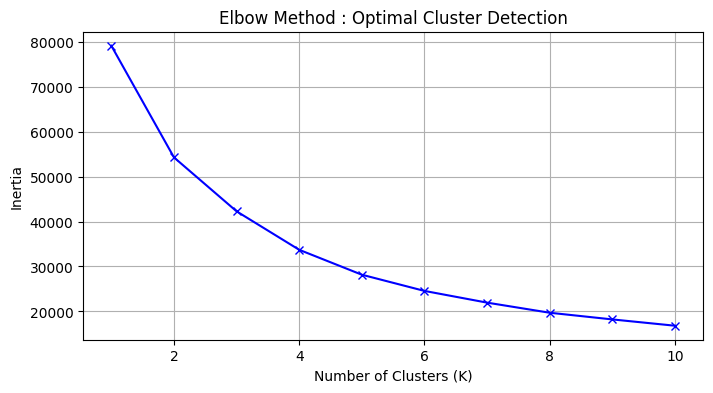


MODULE 5 : CLUSTER DISCOVERY

CLUSTER ASSIGNMENT COMPLETED

CLUSTER DISTRIBUTION
Inherent_Cluster
1    18241
0     4623
2     3523
Name: count, dtype: int64

MODULE 6 : SILHOUETTE VALIDATION

--- CLUSTERING HEALTH REPORT ---

Silhouette Coefficient: 0.4434

INTERPRETATION:
Moderate cluster structure detected.

MODULE 7 : VISUALIZATION


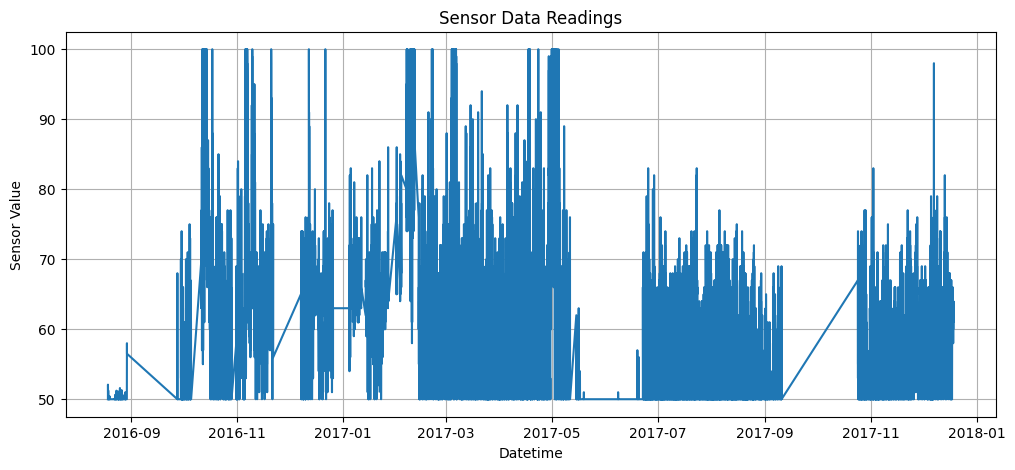

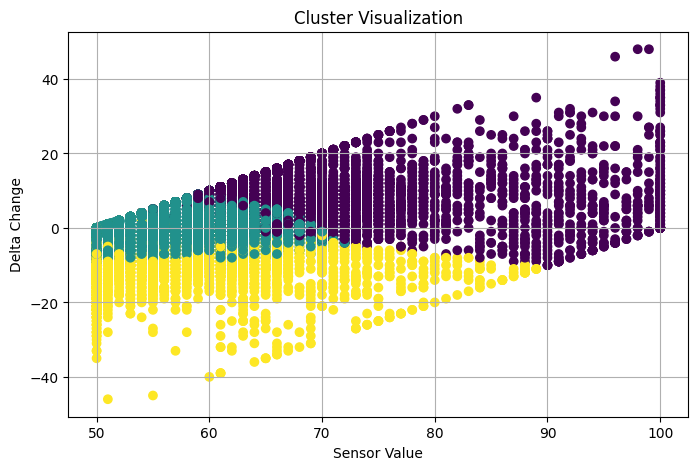


FINAL CLUSTERED PARQUET FILE SAVED

PR_27 PRACTICAL COMPLETED


In [1]:
# ==========================================
# PR_27
# Ensemble Learner and Cross Validation
# Unsupervised Clustering Using Sensor Data
# CSV TO PARQUET WORKFLOW
# ==========================================

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

# ==========================================
# MODULE 1 :
# CSV INGESTION AND PARQUET CONVERSION
# ==========================================

print("\n===================================")
print("MODULE 1 : CSV TO PARQUET CONVERSION")
print("===================================")

"""
DEFINITION:
This module converts CSV data
into Parquet format for
high-speed analytical workflows.
"""

# ---------- LOAD CSV DATASET ----------

df = pd.read_csv("sensor_data.csv")

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- DATETIME CONVERSION ----------

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# ---------- SET DATETIME INDEX ----------

df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

# ---------- CONVERT SENSOR VALUES ----------

df['val'] = pd.to_numeric(
    df['val'],
    errors='coerce'
)

# Remove invalid values
df = df.dropna(subset=['val'])

# Keep required column
df = df[['val']]

# ---------- SAVE AS PARQUET ----------

df.to_parquet(

    "sensor_data.parquet",

    compression='snappy'

)

print("\nPARQUET FILE CREATED SUCCESSFULLY")


# ==========================================
# MODULE 2 :
# LOAD PARQUET DATA
# ==========================================

print("\n===================================")
print("MODULE 2 : LOAD PARQUET DATA")
print("===================================")

"""
DEFINITION:
Parquet acts as the
high-speed analytical working memory.
"""

# ---------- LOAD PARQUET ----------

df = pd.read_parquet(
    "sensor_data.parquet"
)

print("\nPARQUET DATA LOADED")

print("\nDATASET INFO")
print(df.info())


# ==========================================
# MODULE 3 :
# FEATURE STANDARDIZATION
# ==========================================

print("\n===================================")
print("MODULE 3 : FEATURE STANDARDIZATION")
print("===================================")

"""
DEFINITION:
Standardization ensures all features
contribute equally to Euclidean distance.
"""

# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\nCREATING DERIVED FEATURES")

# ---------- DELTA CHANGE ----------

"""
Delta_Change represents
speed of sensor variation.
"""

df['Delta_Change'] = (
    df['val']
    .diff()
    .fillna(0)
)

# ---------- ROLLING VARIANCE ----------

"""
Rolling_Var measures
signal stability.
"""

df['Rolling_Var'] = (
    df['val']
    .rolling(window=10)
    .var()
    .fillna(0)
)

# ---------- FINAL FEATURE MATRIX ----------

X = df[[
    'val',
    'Delta_Change',
    'Rolling_Var'
]]

print("\nFEATURE MATRIX")
print(X.head())

# ---------- STANDARD SCALER ----------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFEATURE STANDARDIZATION COMPLETED")


# ==========================================
# MODULE 4 :
# ELBOW METHOD
# ==========================================

print("\n===================================")
print("MODULE 4 : ELBOW METHOD")
print("===================================")

"""
DEFINITION:
The Elbow Method identifies
the optimal number of clusters.
"""

# ---------- CALCULATE INERTIA ----------

inertia_scores = []

K_range = range(1, 11)

for k in K_range:

    model = KMeans(

        n_clusters=k,

        init='k-means++',

        n_init=10,

        random_state=42

    )

    model.fit(X_scaled)

    inertia_scores.append(
        model.inertia_
    )

print("\nINERTIA SCORES")
print(inertia_scores)

# ---------- ELBOW VISUALIZATION ----------

plt.figure(figsize=(8,4))

plt.plot(

    K_range,

    inertia_scores,

    'bx-'

)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.title(
    "Elbow Method : Optimal Cluster Detection"
)

plt.grid(True)

plt.show()


# ==========================================
# MODULE 5 :
# CLUSTER DISCOVERY
# ==========================================

print("\n===================================")
print("MODULE 5 : CLUSTER DISCOVERY")
print("===================================")

"""
DEFINITION:
K-Means identifies inherent
hidden patterns inside data.
"""

# ---------- SELECT OPTIMAL K ----------

optimal_k = 3

# ---------- FINAL MODEL ----------

final_model = KMeans(

    n_clusters=optimal_k,

    init='k-means++',

    n_init=10,

    random_state=42

)

# ---------- ASSIGN CLUSTERS ----------

cluster_labels = final_model.fit_predict(
    X_scaled
)

# ---------- MERGE CLUSTERS ----------

df_grouped = X.copy()

df_grouped['Inherent_Cluster'] = (
    cluster_labels
)

print("\nCLUSTER ASSIGNMENT COMPLETED")

print("\nCLUSTER DISTRIBUTION")
print(
    df_grouped['Inherent_Cluster']
    .value_counts()
)


# ==========================================
# MODULE 6 :
# SILHOUETTE VALIDATION
# ==========================================

print("\n===================================")
print("MODULE 6 : SILHOUETTE VALIDATION")
print("===================================")

"""
DEFINITION:
Silhouette Score validates
cluster quality and separation.
"""

# ---------- SILHOUETTE SCORE ----------

score = silhouette_score(

    X_scaled,

    cluster_labels

)

print("\n--- CLUSTERING HEALTH REPORT ---")

print(f"\nSilhouette Coefficient: {score:.4f}")

# ---------- INTERPRETATION ----------

if score > 0.5:

    print(
        "\nINTERPRETATION:"
        "\nStrong inherent cluster structure found."
    )

elif score > 0.25:

    print(
        "\nINTERPRETATION:"
        "\nModerate cluster structure detected."
    )

else:

    print(
        "\nINTERPRETATION:"
        "\nWeak cluster separation."
    )


# ==========================================
# MODULE 7 :
# VISUALIZATION
# ==========================================

print("\n===================================")
print("MODULE 7 : VISUALIZATION")
print("===================================")

# ---------- SENSOR DATA VISUALIZATION ----------

plt.figure(figsize=(12,5))

plt.plot(

    df.index,

    df['val']

)

plt.title("Sensor Data Readings")

plt.xlabel("Datetime")

plt.ylabel("Sensor Value")

plt.grid(True)

plt.show()

# ---------- CLUSTER VISUALIZATION ----------

plt.figure(figsize=(8,5))

plt.scatter(

    df_grouped['val'],

    df_grouped['Delta_Change'],

    c=df_grouped['Inherent_Cluster']

)

plt.title("Cluster Visualization")

plt.xlabel("Sensor Value")

plt.ylabel("Delta Change")

plt.grid(True)

plt.show()


# ==========================================
# SAVE FINAL CLUSTERED DATA
# ==========================================

df_grouped.to_parquet(

    "clustered_sensor_data.parquet",

    compression='snappy'

)

print("\nFINAL CLUSTERED PARQUET FILE SAVED")


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_27 PRACTICAL COMPLETED")
print("===================================")